In [1]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import pickle
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')
import sys
import numpy

### SETUP COPULA
sys.path.append("D:/NPC")
#sys.path.append("C:/Users/alessandro/Documents/GitHub/NPC")
import tensorflow as tf
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
device = gpu_devices[0]
# tf.config.experimental.set_memory_growth(device, True)
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle

###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy

gpu_available = tf.test.is_gpu_available('GPU')

gpu_available = tf.config.list_physical_devices('GPU')
print(gpu_available)

print(tf.test.is_gpu_available('GPU:0'))
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#print(device_lib.list_local_devices())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
True


'/device:GPU:0'

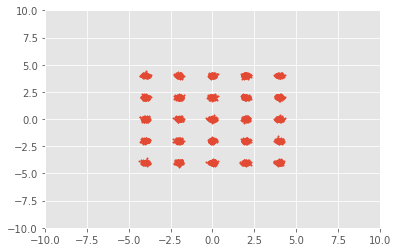

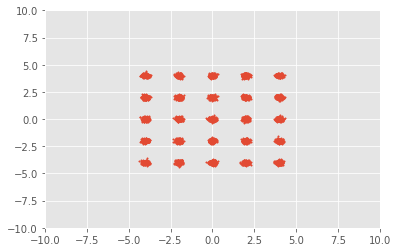

(10000, 2)


In [2]:
x = np.array([(i,j) for i in range(-4, 5, 2) for j in range(-4, 5, 2)] * 400)

x = x + 0.1 * np.random.randn(*x.shape)

plt.scatter(x[:,0], x[:,1], s=2.0)
plt.xlim((-10, 10))
plt.ylim((-10, 10))
plt.show()

np.random.shuffle(x)
plt.scatter(x[:,0], x[:,1], s=2.0)
plt.xlim((-10, 10))
plt.ylim((-10, 10))
plt.show()

print(x.shape)

In [3]:
#### Generate random matrix

cases = 1000        ### Number of samples
vine_type = 'c-vine' # or 'd-vine' or 'c-vine'
method = 'matrix'  # or 'r_matrix'  only with r-vine
binning = False
n_bin = 3
dim = 2                # Dimension of the vine for random r-vine or c-vine or d-vine


if vine_type == 'r-vine':
    
    if method == 'matrix':
        
        ######### REGULAR MATRIX
        r_matrix = np.array([[2, 0, 0, 0, 0],
                             [5, 3, 0, 0, 0],
                             [4, 5, 1, 0, 0],
                             [1, 4, 5, 4, 0],
                             [3, 1, 4, 5, 5]])
        
#         r_matrix = np.array([[3, 0, 0, 0],
#                              [1, 4, 0, 0],
#                              [2, 1, 2, 0],
#                              [4, 2, 1, 1]])
        
#         r_matrix = np.array([[3, 0, 0],
#                              [2, 2, 0],
#                              [1, 1, 1]])

        print(r_matrix)
        
    elif method == 'random':
        
        ##### RANDOM R-MATRIX
        r_matrix, ind_vine, nodes, E = random_r_matrix_gen(dim)
        print(r_matrix)

    E, ind_vine, nodes, matrix_edges = prepare_regular(r_matrix)
    print('matrix_edges',matrix_edges)
    
    ## DEFINE MARGINS
#     margin_fam1 = ['norm','gamma','norm','gamma','norm']
#     theta_fam1 = [[0,1],[2,4],[0,1],[2,4],[0,1]]
    margin_fam1 = ['norm','norm','norm','norm','norm']
    theta_fam1 = [[0,1],[0,1],[0,1],[0,1],[0,1]]
    is_cont1 = [True,True,True,True,True]

    margin_vine = []
    for i in range(0,len(margin_fam1),1):
        mar_p = margin_obj(margin_fam1[i], theta_fam1[i], is_cont1[i])
        margin_vine.append(mar_p)

    for i in range(0,len(margin_fam1),1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')
    
    ######################## DEFINE COPULAS  ###################
    if not binning:
        
#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
#                       [0.5, 0.8, 0.4],
#                       [0.5, 0.3],
#                       [0.9]]

#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8, -0.8],
#                       [0.5, 0.8, 0.4, -0.2],
#                       [0.5, 0.3, -0.7],
#                       [0.9, 0.6],
#                       [0.5]]
        
        margin_cop1 = [['gaussian','student','clayton','gaussian'],
                       ['student','clayton','gaussian'],
                       ['student','gaussian'],
                       ['clayton']]

        theta_cop1 = [[0.3, [0,0.2], 0.7,  -0.8],
                      [[-0.8,0.2], 4.5,  -0.2],
                      [[0,0.5],  -0.7],
                      [0.9]]
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [0.6, 0.5],
#                       [0.7]]

        # margin_cop1 = [['clayton','clayton','clayton'],
        #                ['clayton','clayton'],
        #                ['clayton']]

        # theta_cop1 = [[3.7, 4.8, 5.9],
        #               [6.6, 2.5],
        #               [5.7]]
    else:
        
        margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
                       [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian']]]

        theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
                      [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8],[0.2, 0.3, 0.4]],
                      [[0.3, 0.4, 0.5],[0.3, 0.5, 0.9]],
                      [[0.2, 0.5, 0.9]]] #0.2,0.5,0.9
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8]],
#                       [[0.2, 0.5, 0.9]]]

#         margin_cop1 = [['gaussian','gaussian'],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8],
#                       [[0.2, 0.5, 0.9]]]


    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)

    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

    ################# IF YOU WANT TO USE C-VINE OR D-VINE    ################################### 
elif (vine_type == 'c-vine') | (vine_type == 'd-vine'):
    
    
    r_matrix, ind_vine, nodes, matrix_edges = prepare_vine(vine_type, dim)

    print(r_matrix)

    binning = False
    n_bin = 3
    
    ########## DEFINE MARGINS
    
    margin_vine = []
    for i in range(0,dim,1):
        mar_p = margin_obj('norm', [0,1], True)
        margin_vine.append(mar_p)

    for i in range(0,dim,1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')

    ############## DEFINE COPULAS
    # NN = 0
    tr = 0
    cop_vine = []
    for i in range(dim,1,-1):
        cop_vine1 = []
        for j in range(0,i-1,1):
            if (tr == 0) | (binning == False):
    #             if tr == NN:
    #                 cop_p = cop_par_obj('ind',[])  #
    #                 cop_vine1.append(cop_p)
    #             else:
                cop_p = cop_par_obj('clayton',4.5)  #
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj('gaussian',0.9)
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)
        tr += 1
    
#     margin_cop1 = [['gaussian','student','clayton','gaussian'],
#                    ['student','clayton','gaussian'],
#                    ['student','gaussian'],
#                    ['clayton']]
        
#     theta_cop1 = [[0.3, [0,0.2], 0.7,  -0.8],
#                   [[-0.8,0.2], 4.5,  -0.2],
#                   [[0,0.5],  -0.7],
#                   [0.9]]
    
#     d = len(r_matrix)
#     cop_vine = []
#     for tr in range(0,d-1,1):
#         cop_vine1 = []
#         for col in range(0,d-1-tr,1):
#             if (tr == 0) | (binning == False):
#                 cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
#                 cop_vine1.append(cop_p)
#             else:
#                 cop_vine11 = []
#                 for bb in range(0,n_bin,1):
#                     cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
#                     cop_vine11.append(cop_p)
#                 cop_vine1.append(cop_vine11)
#         cop_vine.append(cop_vine1)

    d = len(r_matrix)
    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

# if binning == True:
#     exc = tf.math.floormod(cases,n_bin)
#     cases = cases - exc

sample, v, v_flip, tau_corr, tau_bins = generate_r_samples(cases, r_matrix, ind_vine, nodes, margin_vine, cop_vine, n_bin, binning)
print(sample)

nodes:
[1 2]
edges:
['(1,2)']
[[2 0]
 [1 1]]
norm [0, 1] norm [0, 1] edge: (1,2)  cop family: clayton theta: 4.5
-----------
[[ 1.223255    1.3258322 ]
 [-1.9151608  -1.6957417 ]
 [ 2.0013187   1.1418924 ]
 ...
 [-0.43168324  0.28255135]
 [ 2.1987572   0.8890382 ]
 [ 0.23039308  0.6969204 ]]


In [4]:
################### DEFINE VINE #################

vine_type = "d-vine"
method = 'matrix' #'matrix' 'optimal'
families = "kercop"
knots = 50

vine_depth = 2 #len(r_matrix)


margin_vine = []
for i in range(0,vine_depth,1):
    mar_p = margin_obj('norm', [0,1], True)
    margin_vine.append(mar_p)
    
vine = vine_obj_bin(vine_type, families, vine_depth, margin_vine, knots, method, r_matrix)

nodes:
[1 2]
edges:
['(1,2)']


In [5]:
param = False
binning = False
n_bin = 3

## Make data divisible for bins and k-fold
# x = dat # sample  #dat
# x = sample ## CHANGE THIS IF YOU WANT TO USE DATA THAT ARE LOADED
x = np.array(x,np.float32)


if binning == True:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin*5)
    else:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin)
    x = x[:tf.shape(x)[0]-exc,:]
else:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],5)
        x = x[:tf.shape(x)[0]-exc,:]

## Prepare copula

sort_n = 'rand'
e = prep_cop(x, vine, sort_n)
print(e)

[[-3.932145   -0.18748656]
 [-2.0194585   4.003387  ]
 [ 3.9409182   0.1245041 ]
 ...
 [ 0.12746531  0.09247218]
 [ 1.8556145  -2.229618  ]
 [ 3.9858985  -1.9523735 ]]


In [9]:
### FITTING
# Parameters:
# - Data: x
# - Parallel: True or False
# - Bandwidth optimization: LL1 or LL2
# - Binning: True or false.    It can be True only if parallel is false
# - n_bin: Select the number of bins
# parallel = False

#gen_dict = {'parallel':True, 'binning':binning, 'param':param, 'vine_depth':vine_depth, 'fitted':False}  #vine_depth
#par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
#npc_dict = {'opt_method':'LL1','batch_paral':3}
#bin_dict = {'n_bin':n_bin}
#save_vine = False
#vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)


vine_depth_fit = 2*dim 
gen_dict = {'parallel':True, 'binning':binning, 'param':param, 'vine_depth':vine_depth_fit, 'fitted':False}  #vine_depth
par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
npc_dict = {'opt_method':'LL1','batch_paral':3}
bin_dict = {'n_bin':n_bin}
save_vine = False
vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)

if save_vine:
    dict_save = {'vine_copulas': vine.copulas, 'r_matrix': vine.r_matrix, 'data': sample}
    pickle_out = open("clay_20_ale","wb")
    pickle.dump(dict_save,pickle_out)
    pickle_out.close()

ResourceExhaustedError: 2 root error(s) found.
  (0) Resource exhausted:  OOM when allocating tensor with shape[10000,9992] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc
	 [[node Tile (defined at D:/NPC\utils\prob_op.py:73) ]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info.

	 [[Cast_1/_14]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info.

  (1) Resource exhausted:  OOM when allocating tensor with shape[10000,9992] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc
	 [[node Tile (defined at D:/NPC\utils\prob_op.py:73) ]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info.

0 successful operations.
0 derived

In [ ]:
sample = vine_copula_sample(vine,10000)

In [ ]:
plt.figure()
plt.scatter(x[:,0], x[:,1], s=2.0)
plt.scatter(sample[:,0], sample[:,1], s=2.0, color='red')
plt.xlim((-10, 10))
plt.ylim((-10, 10))
plt.show()

In [ ]:
############### PREDICT VINE ##################
dim = 0
exp_dim = 100

p, y_ml, y_em = predict_vine(x,vine,dim,exp_dim)

In [ ]:
print(tf.where(tf.math.is_nan(y_ml)))
print(tf.where(tf.math.is_nan(y_em)))

In [ ]:
from scipy import stats
corr = stats.pearsonr(x[:,dim], y_em)

print(corr[0])

plt.figure()
plt.plot(x[:,dim], y_ml, 'r.')
plt.plot(x[:,dim], y_em, 'b.')
plt.title('Correlation: ' + str(corr[0]))
plt.show()

plt.figure()
plt.plot(y_em, x[:,0], 'g.')
plt.plot(x[:,dim], x[:,0], 'y.')
plt.show()

###############

plt.figure()
plt.plot(y_em, x[:,1], 'g.')
plt.plot(x[:,dim], x[:,1], 'y.')
plt.show()

###############

plt.figure()
plt.plot(y_em, x[:,2], 'g.')
plt.plot(x[:,dim], x[:,2], 'y.')
plt.show()